**Decision tree model**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [ ]:
# selected features
X = df_balanced[selected]
y = df_balanced['at_risk']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

**evaluation**

In [ ]:
# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

# Classification Report
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8686411937598915
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      4423
           1       0.95      0.78      0.86      4423

    accuracy                           0.87      8846
   macro avg       0.88      0.87      0.87      8846
weighted avg       0.88      0.87      0.87      8846



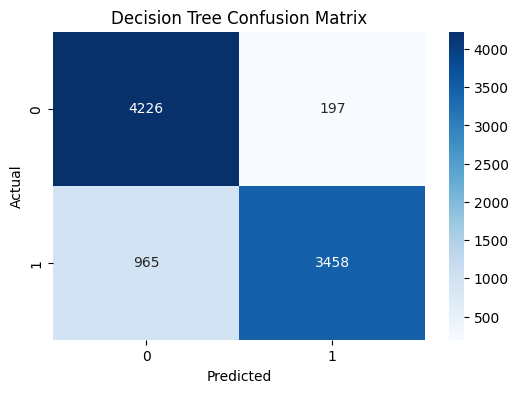

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

** explainability techniques**

1. Visualize Decision Tree

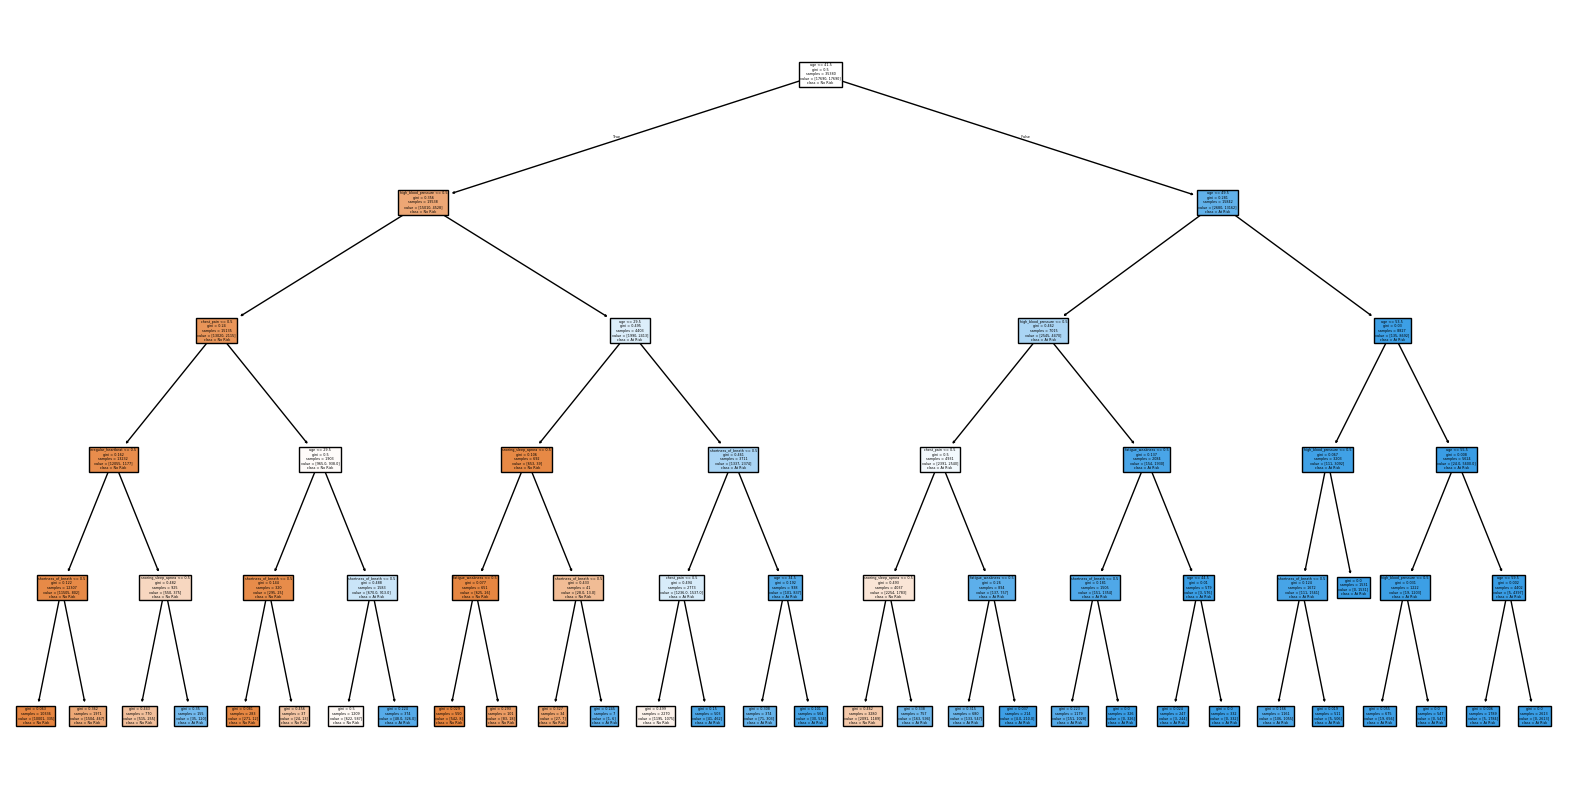

In [ ]:

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Risk', 'At Risk'],
    filled=True
)

plt.show()

2. Feature Importance

In [ ]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

# Sort
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

               Feature  Importance
0                  age    0.689852
2  high_blood_pressure    0.145654
1           chest_pain    0.084057
4  shortness_of_breath    0.036256
9  snoring_sleep_apnea    0.024503
3  irregular_heartbeat    0.017695
5     fatigue_weakness    0.001984
6            dizziness    0.000000
7        neck_jaw_pain    0.000000
8     chest_discomfort    0.000000


Plot Importance

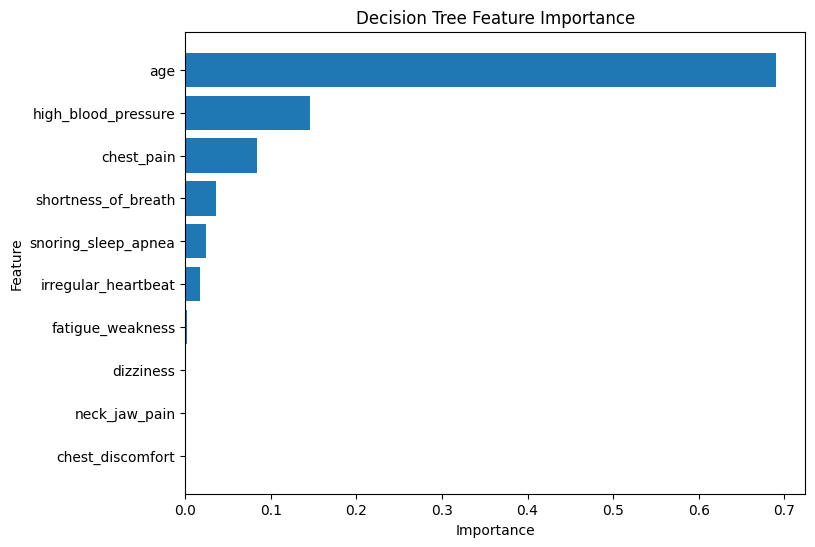

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.show()



3. SHAP Explainability


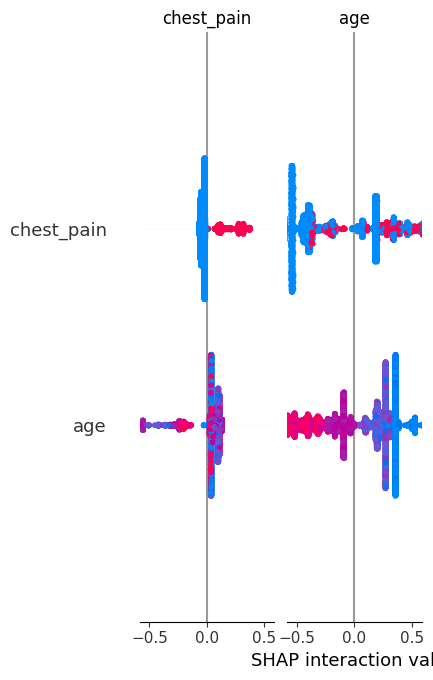

In [ ]:
import shap

# Create explainer
explainer = shap.TreeExplainer(dt_model)

# SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test
)

4. PDP Plot


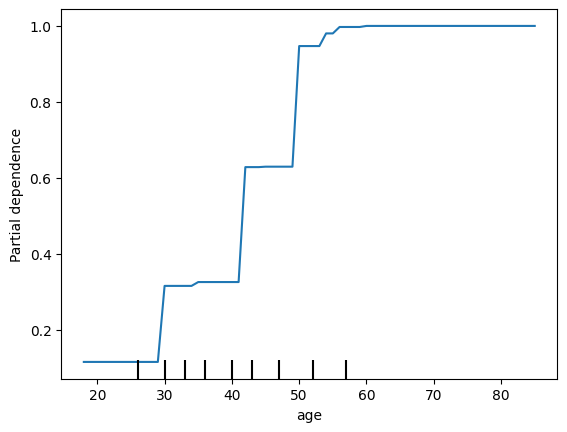

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    dt_model,
    X_test,
    features=['age']
)

plt.show()

5. LIME Explanation

In [ ]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

# Create explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['No Risk', 'At Risk'],
    mode='classification'
)

# Explain one sample
exp = lime_explainer.explain_instance(
    X_test.iloc[0],
    dt_model.predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=6cbc2d8379246d10f70b264e6e910cdc1a7dc40de564a5d129146a60c539e4b5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.